In [5]:
import pandas as pd

df=pd.read_csv("cleaned_stock_data.csv")
df.head


<bound method NDFrame.head of        Company        Open        High         Low       Close   Adj_Close  \
0         AAPL    0.129464    0.130022    0.126674    0.127790    0.098057   
1         AAPL    0.130580    0.131138    0.130580    0.130580    0.100198   
2         AAPL    0.131696    0.133929    0.131696    0.131696    0.101054   
3         AAPL    0.133929    0.133929    0.133929    0.133929    0.102767   
4         AAPL    0.133929    0.135603    0.133371    0.133371    0.102339   
...        ...         ...         ...         ...         ...         ...   
680942      ZS  320.959991  327.850006  319.179993  322.040009  322.040009   
680943      ZS  326.084991  333.269989  324.420013  331.140015  331.140015   
680944      ZS  331.730011  336.989990  329.609985  336.269989  336.269989   
680945      ZS  329.230011  335.700012  325.100006  328.299988  328.299988   
680946      ZS  327.209991  328.000000  317.399994  323.899994  323.899994   

           Volume  Dividends  Sto

In [7]:
import numpy as np
import gudhi as gd
import matplotlib.pyplot as plt

In [13]:

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'Company'])

# Pivot to returns matrix: rows = Date, cols = Company
returns = df.pivot(index='Date', columns='Company', values='Return')
returns = returns.dropna(how='all')

print("returns shape:", returns.shape)
returns.head()

returns shape: (10270, 102)


Company,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AMAT,AMD,AMGN,...,TSLA,TTD,TTWO,TXN,VRSK,VRTX,WBD,WDAY,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
1985-02-01,-0.012930,NaN,NaN,-0.041860,0.000000,NaN,0.005848,-0.007146,-0.014235,0.000000,...,NaN,NaN,NaN,-0.010618,NaN,NaN,NaN,NaN,-0.005780,NaN
1985-02-04,0.021833,NaN,NaN,0.009709,0.014164,NaN,0.005814,-0.021581,0.021661,-0.035712,...,NaN,NaN,NaN,0.002927,NaN,NaN,NaN,NaN,0.000000,NaN
1985-02-05,0.008547,NaN,NaN,0.019230,0.013966,NaN,-0.002849,0.029413,0.000000,-0.037034,...,NaN,NaN,NaN,-0.012646,NaN,NaN,NaN,NaN,0.000000,NaN
1985-02-06,0.016955,NaN,NaN,0.023585,-0.005509,NaN,0.005952,0.014285,-0.017668,-0.019230,...,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,-0.014535,NaN
1985-02-07,-0.004166,NaN,NaN,0.032258,-0.002770,NaN,-0.005917,-0.010564,0.003597,0.000000,...,NaN,NaN,NaN,-0.016749,NaN,NaN,NaN,NaN,0.000000,NaN


In [19]:
mispricing_df = pd.read_csv("mispricing_residuals.csv", index_col='date')
mispricing_df.index = pd.to_datetime(mispricing_df.index)

print("mispricing shape:", mispricing_df.shape)
mispricing_df.head()

mispricing shape: (2042, 102)


,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,AMAT,AMD,AMGN,...,TSLA,TTD,TTWO,TXN,VRSK,VRTX,WBD,WDAY,XEL,ZS
date,,,,,,,,,,,,,,,,,,,,,
1985-04-29,0.0,0.0,0.0,-0.004902,-0.001646,0.0,0.000000,-0.003722,-0.015179,0.000000,...,0.0,0.0,0.0,0.005337,0.0,0.0,0.0,0.0,-0.000616,0.0
1985-05-06,0.0,0.0,0.0,0.000561,0.004929,0.0,0.000346,0.003117,-0.005888,0.000000,...,0.0,0.0,0.0,0.000766,0.0,0.0,0.0,0.0,-0.000908,0.0
1985-05-13,0.0,0.0,0.0,0.001870,-0.005246,0.0,0.000271,0.004637,0.006534,-0.000117,...,0.0,0.0,0.0,-0.005069,0.0,0.0,0.0,0.0,-0.003416,0.0
1985-05-20,0.0,0.0,0.0,-0.001999,-0.003337,0.0,0.002042,0.015184,0.003495,0.006196,...,0.0,0.0,0.0,-0.005136,0.0,0.0,0.0,0.0,-0.000580,0.0
1985-05-28,0.0,0.0,0.0,0.001597,0.005258,0.0,0.002386,-0.006599,-0.001976,-0.000942,...,0.0,0.0,0.0,-0.000769,0.0,0.0,0.0,0.0,0.000442,0.0


In [21]:
WINDOW = 60  # days
STEP   = 5   # days

def rolling_corr_matrices(returns_df, window=60, step=5):
    dates = []
    corr_mats = []
    
    for i in range(window, len(returns_df), step):
        window_data = returns_df.iloc[i-window:i]
        C = window_data.corr()
        dates.append(returns_df.index[i-1])  # end date of window
        corr_mats.append(C)
    
    return dates, corr_mats

corr_dates, corr_mats = rolling_corr_matrices(returns, window=WINDOW, step=STEP)

print("Number of correlation windows:", len(corr_dates))
corr_mats[0].shape

Number of correlation windows: 2042


(102, 102)

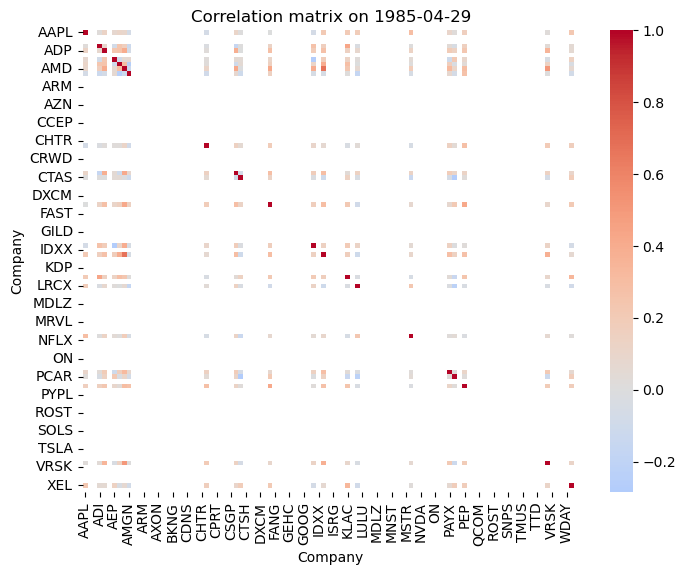

In [23]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mats[0], cmap='coolwarm', center=0)
plt.title(f"Correlation matrix on {corr_dates[0].date()}")
plt.show()

In [25]:
def corr_to_distance(C_df):
    C = C_df.fillna(0).clip(-1, 1)
    D = np.sqrt(2 * (1 - C))
    # zero distance on diagonal
    for col in D.columns:
        D.loc[col, col] = 0.0
    return D

In [31]:
def ph_features_from_distance(D_df, max_dim=1, max_edge_length=None,
                              thr_H0=0.05, thr_H1=0.02):
    """
    D_df: pandas DataFrame, symmetric distance matrix (companies x companies)
    max_dim: maximum homology dimension (1 => H0 and H1)
    max_edge_length: cutoff for filtration (if None, auto-computed)
    thr_H0, thr_H1: persistence thresholds for 'long' bars
    """
    dist_mat = D_df.values
    if np.any(np.isnan(dist_mat)) or np.any(np.isinf(dist_mat)):
        raise ValueError("Distance matrix contains NaN or Inf values")
    
    # Auto-compute max_edge_length if None
    if max_edge_length is None:
        max_edge_length = np.max(dist_mat)
        if max_edge_length > 0:
            max_edge_length *= 1.01  # small epsilon to include the max edge
        else:
            max_edge_length = 1.0  # fallback for zero matrix
    
    rips_complex = gd.RipsComplex(distance_matrix=dist_mat,
                                  max_edge_length=max_edge_length)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=max_dim + 1)  # note: max_dimension is dim+1 in Gudhi
    diag = simplex_tree.persistence()
    
    # Rest of your code unchanged
    H0 = [p for dim, p in diag if dim == 0]
    H1 = [p for dim, p in diag if dim == 1]
    
    def summarize(bars, threshold):
        pers = [b[1] - b[0] for b in bars if b[1] != float('inf')]
        if len(pers) == 0:
            return dict(count_long=0, sum_pers=0.0, max_pers=0.0)
        pers = np.array(pers)
        count_long = int((pers > threshold).sum())
        return dict(
            count_long=count_long,
            sum_pers=float(pers.sum()),
            max_pers=float(pers.max())
        )
    
    f0 = summarize(H0, threshold=thr_H0)
    f1 = summarize(H1, threshold=thr_H1)
    
    features = {
        'H0_count_long': f0['count_long'],
        'H0_sum_pers': f0['sum_pers'],
        'H0_max_pers': f0['max_pers'],
        'H1_count_long': f1['count_long'],
        'H1_sum_pers': f1['sum_pers'],
        'H1_max_pers': f1['max_pers'],
    }
    return features, diag

In [33]:
topo_rows = []
diagrams_by_date = {}  # optional, for plotting later

for date, C_df in zip(corr_dates, corr_mats):
    # Use all companies present in this correlation matrix
    D_df = corr_to_distance(C_df)

    feats, diag = ph_features_from_distance(
        D_df,
        max_dim=1,
        max_edge_length=None,
        thr_H0=0.05,
        thr_H1=0.02
    )
    feats['date'] = date
    topo_rows.append(feats)
    
    # Keep a few diagrams for visualization (optional)
    diagrams_by_date[date] = diag

topo_df = pd.DataFrame(topo_rows).set_index('date')
print("topology_features shape:", topo_df.shape)
topo_df.head()

topology_features shape: (2042, 6)


,H0_count_long,H0_sum_pers,H0_max_pers,H1_count_long,H1_sum_pers,H1_max_pers
date,,,,,,
1985-04-29,101,137.339838,1.414214,4,0.220785,0.052675
1985-05-06,101,137.257825,1.414214,6,0.292965,0.061226
1985-05-13,101,136.848218,1.414214,6,0.233746,0.072834
1985-05-20,101,136.750450,1.414214,7,0.376994,0.078272
1985-05-28,101,136.750544,1.414214,3,0.330536,0.116506


In [35]:
topo_df.to_csv("topology_features.csv")

/opt/anaconda3/lib/python3.12/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


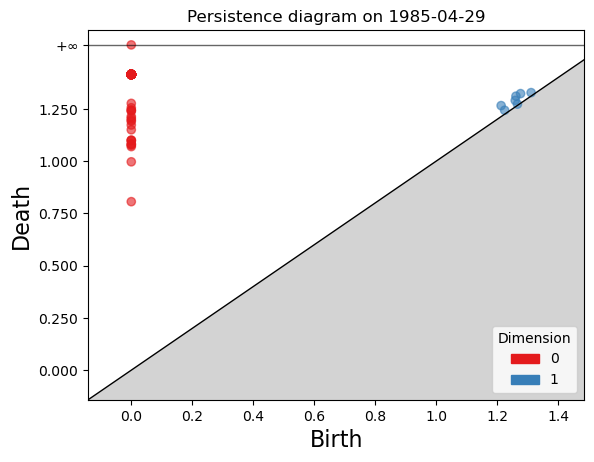

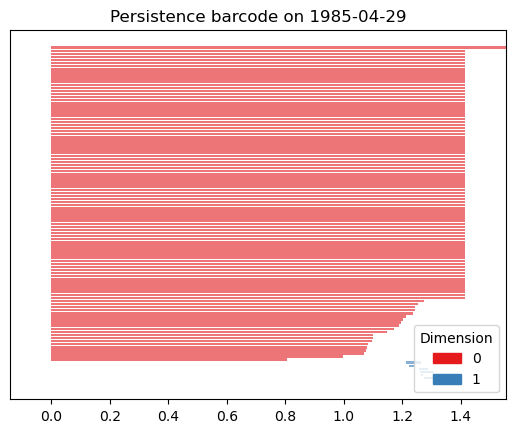

In [37]:
sample_date = corr_dates[0]
sample_diag = diagrams_by_date[sample_date]

gd.plot_persistence_diagram(sample_diag)
plt.title(f"Persistence diagram on {sample_date.date()}")
plt.show()

gd.plot_persistence_barcode(sample_diag)
plt.title(f"Persistence barcode on {sample_date.date()}")
plt.show()

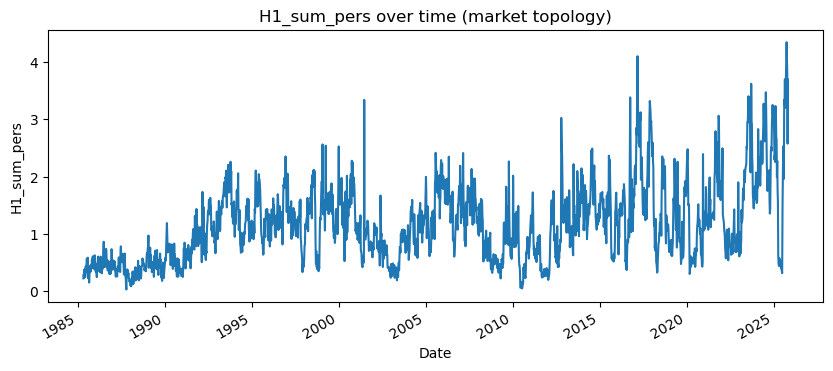

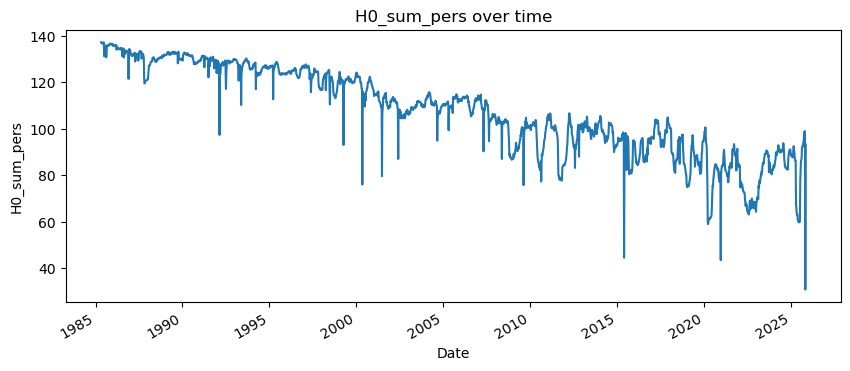

In [39]:
plt.figure(figsize=(10, 4))
topo_df['H1_sum_pers'].plot()
plt.title("H1_sum_pers over time (market topology)")
plt.xlabel("Date")
plt.ylabel("H1_sum_pers")
plt.show()

plt.figure(figsize=(10, 4))
topo_df['H0_sum_pers'].plot()
plt.title("H0_sum_pers over time")
plt.xlabel("Date")
plt.ylabel("H0_sum_pers")
plt.show()